In [55]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries for dataset, model, and evaluation
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Set plot style
sns.set(style="whitegrid")


In [56]:
digits = load_digits()
X = pd.DataFrame(digits.data, columns = digits.feature_names)
y = pd.Series(digits.target, name = 'target')

X.shape

(1797, 64)

In [57]:
y.value_counts()

target
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64

In [58]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 64 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_

In [59]:
X.describe()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2, stratify = y)

In [61]:
X_train.shape

(1437, 64)

In [62]:
X_test.shape

(360, 64)

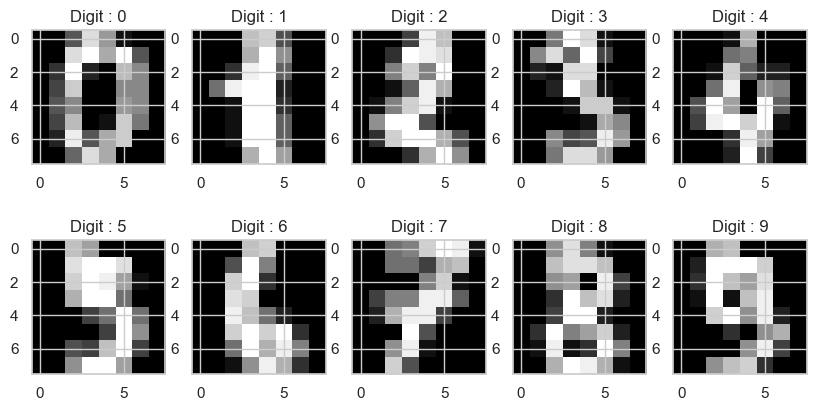

In [63]:
fig, axes = plt.subplots(2,5, figsize=(10,5))
for digit in range(10):
    index = np.where(y == digit)[0][0]
    image = X.iloc[index].values.reshape(8,8)
    ax = axes[digit // 5, digit%5]
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Digit : {digit}')
plt.show()


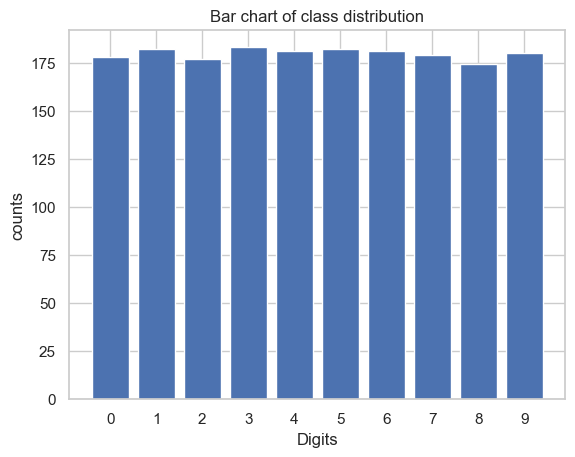

In [64]:
class_counts = y.value_counts().sort_index()
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Digits")
plt.ylabel("counts")
plt.title("Bar chart of class distribution")
plt.xticks(range(10))
plt.show()

In [65]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_pca.shape


(1797, 2)

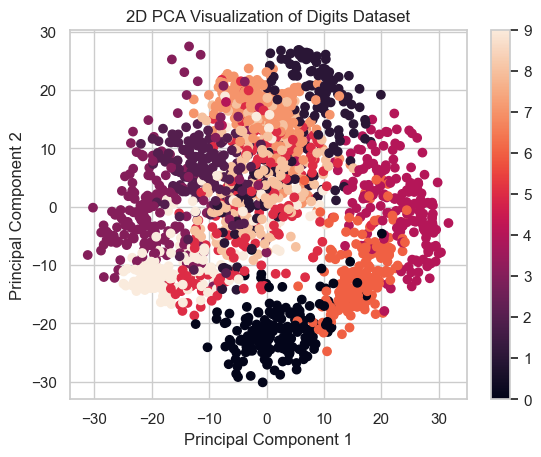

In [66]:
plt.figure()
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Visualization of Digits Dataset')
plt.colorbar(scatter)
plt.show()

In [67]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
scalar.fit(X_train)

X_train_scaled = scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier



In [69]:
lr = LogisticRegression(max_iter = 5000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled) 

In [70]:
print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision (macro):", precision_score(y_test, y_pred_lr, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_lr, average='macro'))
print("F1 (macro):", f1_score(y_test, y_pred_lr, average='macro'))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


Logistic Regression Results:
Accuracy: 0.9722222222222222
Precision (macro): 0.9721260358102464
Recall (macro): 0.9719047619047618
F1 (macro): 0.9719402197048348
Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 32  0  1  1  0  0  0  2  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  4  0  0  0  0  0  0 31  0]
 [ 0  0  0  0  0  0  0  0  1 35]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.

In [71]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)


In [72]:
print("KNN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision (macro):", precision_score(y_test, y_pred_knn, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_knn, average='macro'))
print("F1 (macro):", f1_score(y_test, y_pred_knn, average='macro'))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))


KNN Results:
Accuracy: 0.9638888888888889
Precision (macro): 0.9645896987673304
Recall (macro): 0.9637215787215787
F1 (macro): 0.9634399725952825
Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  1 36  0  0  0  0  0  0]
 [ 0  0  0  0 34  0  0  2  0  0]
 [ 0  0  0  0  0 36  0  0  0  1]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  1  0 35  0  0]
 [ 0  3  1  0  0  0  0  0 31  0]
 [ 0  0  0  0  1  0  1  1  1 32]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95    

In [73]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)


In [74]:
print("Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision (macro):", precision_score(y_test, y_pred_dt, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_dt, average='macro'))
print("F1 (macro):", f1_score(y_test, y_pred_dt, average='macro'))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Results:
Accuracy: 0.8166666666666667
Precision (macro): 0.8156276783144355
Recall (macro): 0.815909480909481
F1 (macro): 0.8148410665784604
Confusion Matrix:
 [[35  0  0  0  0  0  0  0  1  0]
 [ 0 26  2  1  1  0  1  1  4  0]
 [ 1  0 27  3  0  1  2  0  1  0]
 [ 0  0  2 29  0  1  1  2  0  2]
 [ 1  0  1  1 30  0  2  0  1  0]
 [ 0  0  0  0  1 35  0  0  0  1]
 [ 1  1  0  0  1  2 30  0  1  0]
 [ 0  1  1  0  2  0  0 31  0  1]
 [ 0  3  1  0  0  1  2  2 24  2]
 [ 0  0  1  3  0  0  0  2  3 27]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95        36
           1       0.84      0.72      0.78        36
           2       0.77      0.77      0.77        35
           3       0.78      0.78      0.78        37
           4       0.86      0.83      0.85        36
           5       0.88      0.95      0.91        37
           6       0.79      0.83      0.81        36
           7       0.82      0.86     